In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


from prep_ciber_dat_lens import *
from forecast_cib_lens import *
from kappa_auto_cross_fns import *
from kappa_plotting_fns import *
from mock_lens_test import *
from lens_response import *

from ciber.core.powerspec_pipeline import *
from ciber.core.ps_pipeline_go import *
from ciber.io.ciber_data_utils import *
from ciber.plotting.plotting_fns import plot_map
from ciber.cross_correlation.galaxy_cross import *
from ciber.processing.numerical import sigma_clip_maskonly, iter_sigma_clip_mask

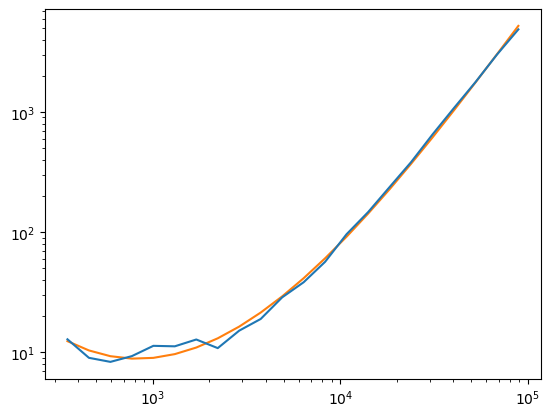

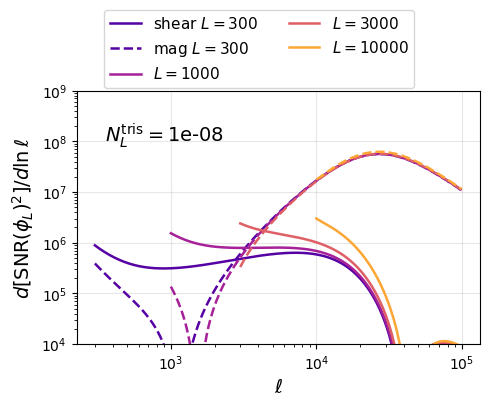

In [4]:
from lens_response import load_ciber_f25_spectrum, plot_snr_shear_vs_mag

# # Load TM1 (J-band, 1.1 um) F25 spectrum
# cell_interp, lb, cl = load_ciber_f25_spectrum(inst=1)  # or inst=2 for H-band

# Smooth spline in log-log space — most faithful to the data shape overall
cell_interp, lb, cl = load_ciber_f25_spectrum(inst=1, smooth=True,
                                     smooth_model='spline', smooth_factor=0.5)


pf = lb*(lb+1)/(2*np.pi)
plt.figure()
plt.errorbar(lb, pf*cl)
plt.plot(lb, pf*cell_interp(lb))

plt.xscale('log')
plt.yscale('log')
plt.show()

# Load CIBER data with spline smoothing
cell_interp, lb, cl = load_ciber_f25_spectrum(
    inst=1, smooth=True, smooth_model='spline'
)

# # Compare 1D vs exact 2D at L=300
# fig = plot_response_comparison_1d_vs_exact2d(
#     L=300,
#     ellmin=300,
#     ellmax=100000,
#     Nell=300,
#     Nphi=1000,  # ~10 seconds
#     cell_interp=cell_interp,
#     N_tris=10**(-8)
# )



fig = plot_snr_shear_vs_mag(
    L_values=[300, 1000, 3000, 10000],
    A=None, B=None, n=None,          # ignored when cell_interp is set
    ellmin=300, ellmax=100000,
    N_tris=1e-8,
    show_squeezed=False,
    cell_interp=cell_interp,
    exact_response=False,
    ylim=[1e4, 1e9],
    bbox_anchor=[0.05, 1.35],
    legend_fs=11,
    figsize=(5, 4.5)
)

fig.savefig('../figures/shear_vs_mag_Nell=1e-8_vary_L.pdf', bbox_inches='tight')


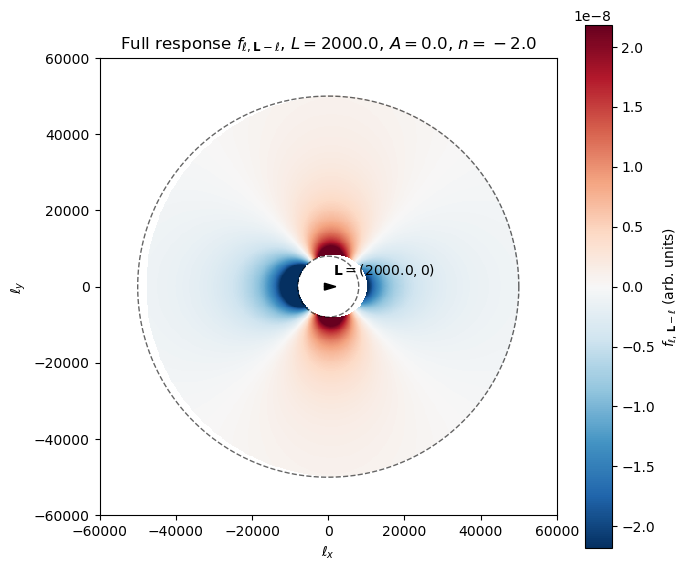

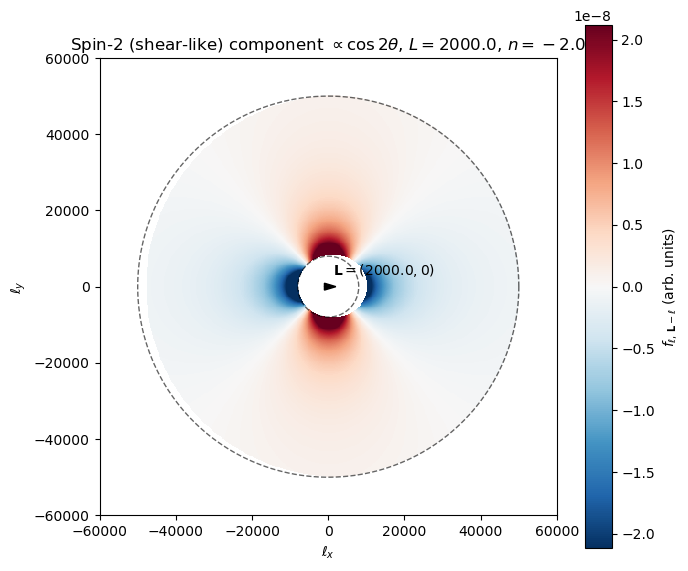

In [27]:
"""
Plot the (approximate) shear-response kernel f_{ℓ,L-ℓ} in 2D Fourier space
for a power-law+Poisson intensity power spectrum: C_ℓ = A + B ℓ^n.

Implements your Appendix-B power-law algebra (Eq. B10-type form), with L
chosen along +x so cosθ = l_x/|l| and cos2θ = (l_x^2-l_y^2)/|l|^2.

Also plots the pure spin-2 (cos2θ) component, which is the piece most
closely associated with "shear-only" weighting.

Author: (adapted to your notes)
"""





# ---- User-tunable parameters ----
L = 2000.0

# Power spectrum model: C_ell = A + B ell^n
# A: Poisson (flat) term. B,n: scale-dependent clustering term.
A = 0.0          # set >0 to include a Poisson piece (will add isotropic response)
B = 1.0
n = -2.0

# Fourier-space region to display
ell_plot_max = 60000.0
Npix = 501

# Annulus used in QE (optional masking in the plot)
ellmin = 8000.0
ellmax = 50000.0

# Choose mask style: both legs in band is what matters for the QE integral
use_both_legs = True
# ---------------------------------

ax1d, ellx, elly = make_ell_grid(ell_plot_max, Npix)

f_full = response_powerlaw_full(ellx, elly, L=L, A=A, B=B, n=n)
f_spin2 = response_powerlaw_spin2_only(ellx, elly, L=L, B=B, n=n)

if ellmin is not None and ellmax is not None:
    if use_both_legs:
        m = both_legs_mask(ellx, elly, L=L, ellmin=ellmin, ellmax=ellmax)
    else:
        m = annulus_mask(ellx, elly, ellmin=ellmin, ellmax=ellmax)

    f_full = np.where(m, f_full, np.nan)
    f_spin2 = np.where(m, f_spin2, np.nan)

plot_response_2d(
    ax1d, f_full,
    title=rf"Full response $f_{{\ell,\mathbf{{L}}-\ell}}$, $L={L}$, $A={A}$, $n={n}$",
    L=L, ellmin=ellmin, ellmax=ellmax
)
plot_response_2d(
    ax1d, f_spin2,
    title=rf"Spin-2 (shear-like) component $\propto\cos 2\theta$, $L={L}$, $n={n}$",
    L=L, ellmin=ellmin, ellmax=ellmax
)

plt.show()

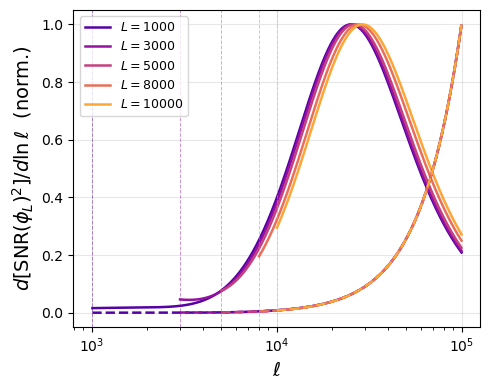

In [63]:
def plot_snr_integrand(
    L_values,
    A,
    B,
    n,
    ellmin,
    ellmax,
    Nell=600,
    normalize=True,
    N_tris_list=[1e-9, 1e-8, 1e-7],
    linestyles=['solid', 'dashed', 'dashdot'],
    C_L=1.0,
):
    """
    Plot d[SNR(phi_L)^2]/d(ln ell) vs ell for each L in L_values.

    Parameters
    ----------
    normalize : bool
        If True, normalise each curve to its peak (shape comparison).
        If False, show raw amplitudes (arb. units).
    """
    ell_arr = np.geomspace(ellmin, ellmax, Nell)
    colors  = plt.cm.plasma(np.linspace(0.15, 0.80, len(L_values)))

    fig, ax = plt.subplots(figsize=(5, 4))

    for nidx, N_tris in enumerate(N_tris_list):
            
        for L, col in zip(L_values, colors):
            
            if nidx==0:
                label = rf"$L={L}$"
            else:
                label = None
            
            dFiso, dFquad = fisher_integrands(ell_arr, L=L, A=A, B=B, n=n)
            g = dFiso + dFquad          # total  dN_L^{-1}/d(ln ell)

            # Cumulative Gaussian inverse-noise up to each ell:
            #   I_cum(ell) = int_{ellmin}^{ell} g(ell') d(ln ell')
            dlnell = np.gradient(np.log(ell_arr))
            I_cum  = np.cumsum(g * dlnell)

            # SNR^2(ell_max) = C_L * I_cum / (1 + N_tris * I_cum)
            # Differentiating with respect to ln(ell_max):
            #   d[SNR^2]/d(ln ell) = C_L * g(ell) / (1 + N_tris * I_cum(ell))^2
            # Turnover when N_tris * I_cum ~ 1, i.e. I_cum ~ 1/N_tris.
            snr_integrand = C_L * g / (1.0 + N_tris * I_cum)**2

            ellmask = (ell_arr > L)
            integrand = snr_integrand
            if normalize:
                peak = np.nanmax(integrand[ellmask])
                if peak > 0:
                    integrand[ellmask] = integrand[ellmask] / peak

            ax.plot(ell_arr[ellmask], integrand[ellmask], color=col, lw=1.8, label=label, linestyle=linestyles[nidx])

    # Mark L values on the x-axis for reference
    for L, col in zip(L_values, colors):
        ax.axvline(L, color=col, lw=0.7, ls="--", alpha=0.45)

    ax.set_xscale("log")
    if not normalize:
        ax.set_yscale("log")
    ax.set_xlabel(r"$\ell$", fontsize=14)
    ylabel = (r"$d[\mathrm{SNR}(\phi_L)^2]/d\ln\ell$  (norm.)"
              if normalize else
              r"$d[\mathrm{SNR}(\phi_L)^2]/d\ln\ell$  (arb. units)")
    ax.set_ylabel(ylabel, fontsize=14)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()
    return fig


A = 1e-7
B = 1e0

fig = plot_snr_integrand(L_values=[1000, 3000, 5000, 8000, 10000], A=A, B=B, n=-2,
                         ellmin=1000, ellmax=100000, normalize=True,
                        N_tris_list=[1e-8, 1e-11])





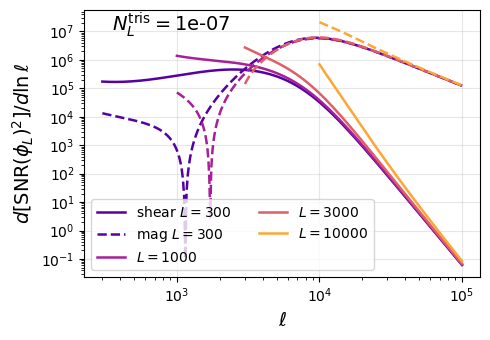

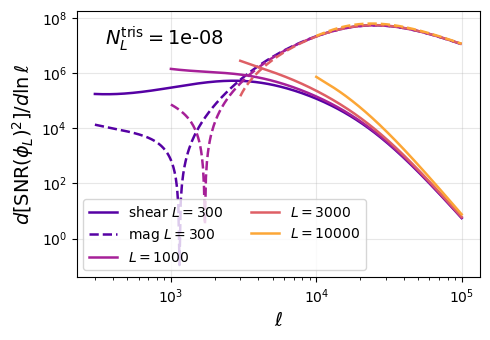

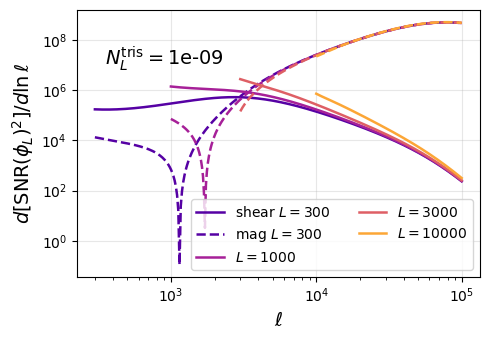

In [30]:

# def plot_snr_shear_vs_mag(
#     L_values,
#     A,
#     B,
#     n,
#     ellmin,
#     ellmax,
#     Nell=300,
#     Ntheta=400,
#     N_tris=1e-9,
#     C_L=1.0,
#     show_squeezed=True,
#     figsize=(5, 3.5)
# ):
#     """
#     Single plot of d[SNR(phi_L)^2]/d(ln ell) split into shear and magnification,
#     using the full 2D integral (no squeezed-limit approximation).

#     Each L gets its own color.  Solid = shear (quad), dashed = magnification (iso).
#     Curves start at ell = L (no contribution from ell < L).
#     If show_squeezed=True, squeezed-limit curves are overlaid in grey.
#     Trispectrum suppression via N_tris uses the cumulative Fisher from ell=L onward.
#     """
#     fig, ax = plt.subplots(figsize=figsize)
#     colors = plt.cm.plasma(np.linspace(0.15, 0.80, len(L_values)))

#     ax.text(350, 1e7, '$N_{L}^{\\rm tris} = $'+str(N_tris), fontsize=14)
#     for i, (L, col) in enumerate(zip(L_values, colors)):
#         # Only use ell >= L
#         ell_arr = np.geomspace(max(ellmin, L), ellmax, Nell)

#         # --- Full 2D integrands ---
#         dF_iso, dF_quad, dF_cross = fisher_integrands_full2d(
#             ell_arr, L=L, A=A, B=B, n=n, Ntheta=Ntheta
#         )
#         g_tot  = dF_iso + dF_quad + dF_cross
#         dlnell = np.gradient(np.log(ell_arr))
#         I_cum  = np.cumsum(g_tot * dlnell)
#         w      = C_L / (1.0 + N_tris * I_cum)**2

#         snr_quad = w * dF_quad
#         snr_iso  = w * dF_iso

#         lbl = rf"$L={L}$"
#         ax.plot(ell_arr, snr_quad, color=col, ls="-",  lw=1.8,
#                 label=rf"shear {lbl}" if i == 0 else lbl)
#         ax.plot(ell_arr, snr_iso,  color=col, ls="--", lw=1.8,
#                 label=rf"mag {lbl}"   if i == 0 else None)

#         # --- Squeezed-limit overlay ---
#         if show_squeezed:
#             dFiso_sq, dFquad_sq = fisher_integrands(ell_arr, L=L, A=A, B=B, n=n)
#             g_sq = dFiso_sq + dFquad_sq
#             I_sq = np.cumsum(g_sq * dlnell)
#             w_sq = C_L / (1.0 + N_tris * I_sq)**2
#             ax.plot(ell_arr, w_sq * dFquad_sq, color="0.65", ls="-",  lw=0.9,
#                     label="shear (squeezed)" if i == 0 else None)
#             ax.plot(ell_arr, w_sq * dFiso_sq,  color="0.65", ls="--", lw=0.9,
#                     label="mag (squeezed)"   if i == 0 else None)

#     ax.set_xscale("log")
#     ax.set_yscale("log")
#     ax.set_xlabel(r"$\ell$", fontsize=14)
#     ax.set_ylabel(r"$d[\mathrm{SNR}(\phi_L)^2]/d\ln\ell$", fontsize=14)
#     ax.grid(alpha=0.3)
#     ax.legend(fontsize=10, ncol=2)
#     plt.tight_layout()
#     return fig



A = 1e-7
B = 1e0

for N_tris in [1e-7, 1e-8, 1e-9]:

    fig = plot_snr_shear_vs_mag(
        L_values=[300, 1000, 3000, 10000],
        A=A, B=B, n=-2.0,
        ellmin=100, ellmax=100000,
        N_tris=N_tris,
        show_squeezed=False
    )


# fig = plot_snr_shear_vs_mag(
#     L_values=[300, 1000, 3000, 10000],
#     A=A, B=B, n=-1.5,
#     ellmin=100, ellmax=100000,
#     N_tris=1e-7,
#     show_squeezed=False
# )


1.1111111111111111e-07 1.0 -2.0


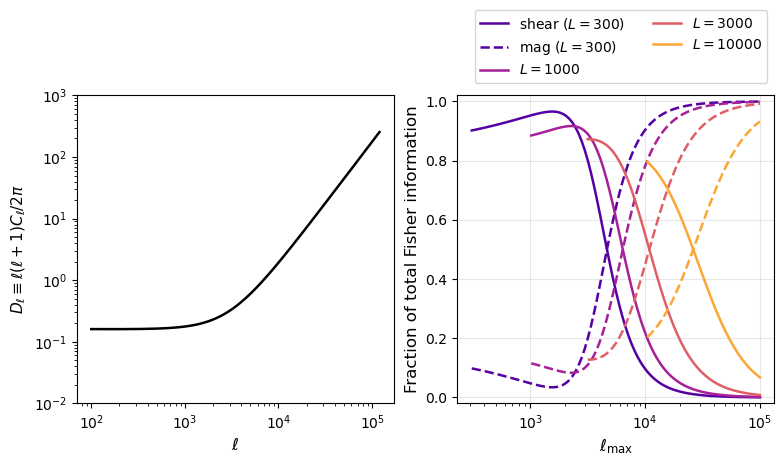

In [49]:
def plot_shear_vs_mag_vs_ellmax(
    L_values,
    ellmin,
    ellmax_arr,
    ell_pivot=5000.0,
    B=1.0,
    Nell=600,
):
    """
    Show how shear (quadrupolar) and magnification (isotropic) Fisher information
    split as a function of the upper integration limit ell_max.

    Spectrum: C_ell = A + B * ell^{-2}  with  A = B / ell_pivot^2
    (the two terms contribute equally at ell = ell_pivot).

    Parameters
    ----------
    L_values   : list of floats  – large-scale multipoles to show.
    ellmin     : float           – lower integration limit (held fixed).
    ellmax_arr : 1-D array       – upper limits to sweep over.
    ell_pivot  : float           – pivot scale where A = B * ell_pivot^{-2}.
    B          : float           – overall amplitude (ratio is independent of B).
    Nell       : int             – grid points per ell_arr evaluation.
    """
    n = -2.0
    A = B / ell_pivot**2
    
    print(A, B, n)

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    # --- left panel: mock power spectrum D_ell ---
    ell_plot = np.geomspace(max(ellmin, 10), ellmax_arr[-1] * 1.2, 500)
    D_ell    = ell_plot * (ell_plot + 1) * C_ell(ell_plot, A, B, n) / (2.0 * np.pi)
    axes[0].plot(ell_plot, D_ell, "k-", lw=1.8)
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].set_xlabel(r"$\ell$", fontsize=12)
    axes[0].set_ylabel(r"$D_\ell \equiv \ell(\ell+1)C_\ell/2\pi$", fontsize=11)
    axes[0].set_ylim(1e-2, 1e3)
    # --- right panel: shear / mag fractions vs ell_max ---
    colors = plt.cm.plasma(np.linspace(0.15, 0.80, len(L_values)))

    for i, (L, col) in enumerate(zip(L_values, colors)):
        # Only compute for ell_max >= L (need modes up to L to reconstruct L)
        valid_ellmax = ellmax_arr[ellmax_arr >= L]
        
        shear_fracs = []
        mag_fracs   = []

        for ellmax in valid_ellmax:
            if ellmax <= ellmin:
                shear_fracs.append(np.nan)
                mag_fracs.append(np.nan)
                continue

            ell_arr        = np.geomspace(ellmin, ellmax, Nell)
            dFmag, dFshear = fisher_integrands(ell_arr, L=L, A=A, B=B, n=n)
            dlnell         = np.gradient(np.log(ell_arr))
            Fmag           = np.trapz(dFmag   * dlnell)
            Fshear         = np.trapz(dFshear * dlnell)
            Ftot           = Fmag + Fshear

            shear_fracs.append(Fshear / Ftot if Ftot > 0 else np.nan)
            mag_fracs.append(  Fmag   / Ftot if Ftot > 0 else np.nan)

        # Condensed labels: first L gets "shear (L=...)" and "mag (L=...)", rest just "L=..."
        if i == 0:
            shear_lbl = rf"shear ($L={L}$)"
            mag_lbl   = rf"mag ($L={L}$)"
        else:
            shear_lbl = rf"$L={L}$"
            mag_lbl   = None  # Skip label for mag on subsequent L values
        
        axes[1].plot(valid_ellmax, shear_fracs, color=col, ls="-",  lw=1.8, label=shear_lbl)
        axes[1].plot(valid_ellmax, mag_fracs,   color=col, ls="--", lw=1.8, label=mag_lbl)

    axes[1].set_xscale("log")
    axes[1].set_ylim(-0.02, 1.02)
    axes[1].set_xlabel(r"$\ell_{\rm max}$", fontsize=12)
    axes[1].set_ylabel(r"Fraction of total Fisher information", fontsize=12)
    axes[1].grid(alpha=0.3)
    axes[1].legend(fontsize=10, ncol=2, bbox_to_anchor=[1.0, 1.3])

#     plt.tight_layout()
    return fig


# ---------------------------------------------------------------------------
# Main: generate the shear-vs-mag figure
# ---------------------------------------------------------------------------


L_values   = [300, 1000, 3000, 10000]
ellmin     = 100.0
ell_pivot  = 3000.0
ellmax_arr = np.geomspace(200, 100000, 100)

fig = plot_shear_vs_mag_vs_ellmax(
    L_values=L_values,
    ellmin=ellmin,
    ellmax_arr=ellmax_arr,
    ell_pivot=ell_pivot,
)
plt.show()
    
    

Saved response_quad_L100.png
Saved response_quad_L500.png
Saved response_quad_L2000.png
Saved response_quad_L8000.png
Saved response_quad_L20000.png


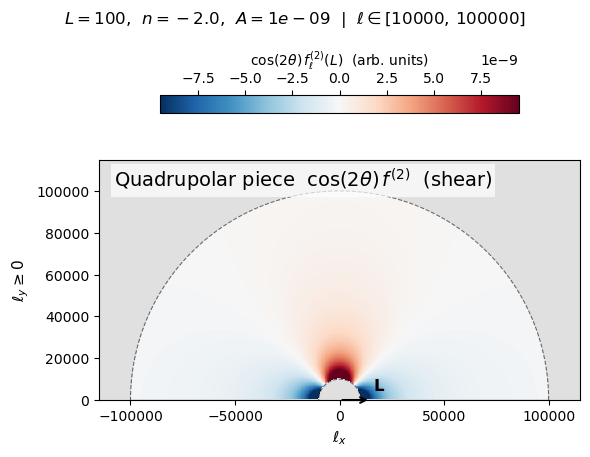

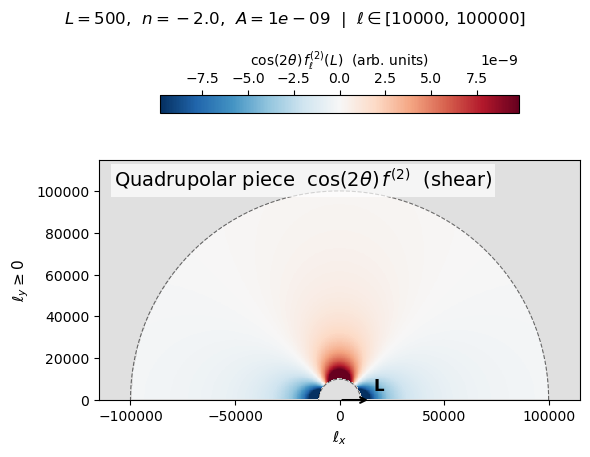

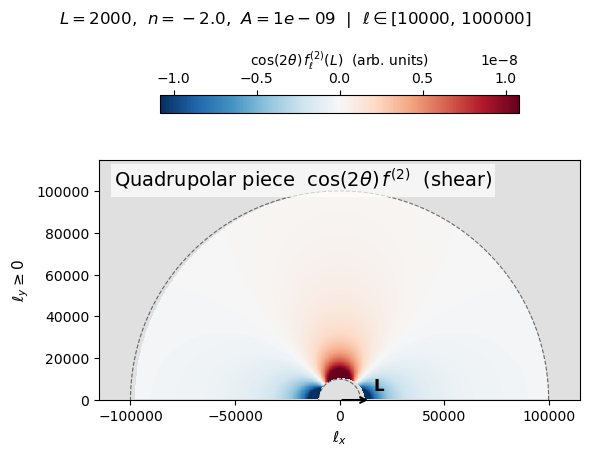

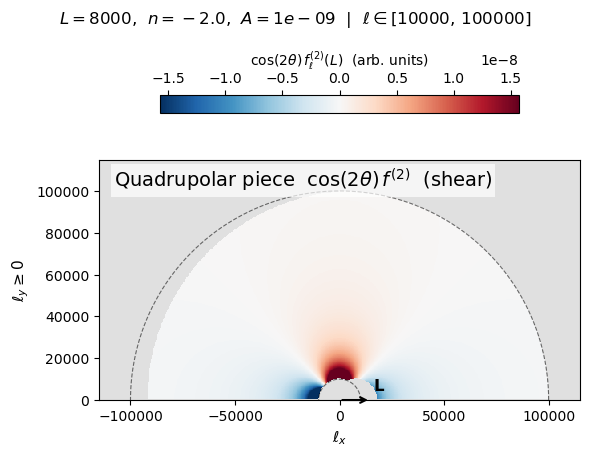

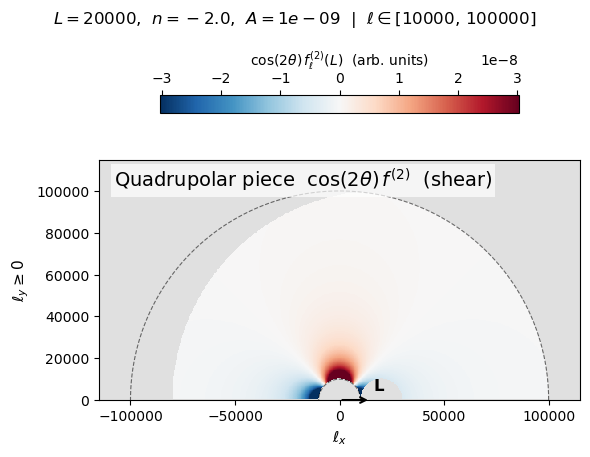

In [2]:
"""
Plot the 2D response kernel f_{ell, L-ell} split into:
  - isotropic (m=0) part: responds to magnification/variance modulation
  - quadrupolar (spin-2 / m=2) part: the "shear-only" piece

Only the upper half-plane (ell_y >= 0) is shown, since f is symmetric
under (ell_x, ell_y) -> (-ell_x, -ell_y) with L along +x.

Power spectrum model: C_ell = A + B * ell^n

The full response (from Appendix B Eq. B1) is decomposed as:
    f_{ell, L-ell} = f_iso(ell, L) + cos(2theta) * f_quad_amp(ell, L)

where theta is the angle between ell and L (taken along +x).

Isotropic piece (angle-independent):
    f_iso = C * (2 + s) - (L/2ell) * D+ C

Quadrupolar amplitude (coefficient of cos 2theta):
    f_quad_amp = C * s - (L/2ell) * D- C

with log-derivatives:
    s   = d ln C / d ln ell  =  n B ell^n / C
    s2  = d^2 ln C / (d ln ell)^2  =  s(n - s)
    D+C = C * (s + s^2 + s2)
    D-C = C * (s^2 + s2 - s)
"""




# ---- Tunable parameters ------------------------------------------------
L_values = [100, 500, 2000, 8000, 20000]    # large-scale multipoles to show

# Power spectrum C_ell = A + B * ell^n
A = 1e-9                        # Poisson (flat) floor; set >0 to see
                                 # isotropic piece swell up
B = 1.0                          # clustering amplitude (arb. units)
n = -2.0                         # power-law slope (negative = red spectrum)

# QE reconstruction annulus
ellmin =  10000.0
ellmax = 100_000.0

# Grid
ell_plot_max = ellmax * 1.15
Npix         = 601               # odd -> zero mode is centred
# -----------------------------------------------------------------------

ax1d         = np.linspace(-ell_plot_max, ell_plot_max, Npix)
ellx, elly   = np.meshgrid(ax1d, ax1d, indexing="xy")

# Index of the first row with elly >= 0
ny_half      = (Npix + 1) // 2
ax1d_half    = ax1d[ny_half - 1:]         # positive ell_y values
extent_half  = [ax1d[0], ax1d[-1], 0.0, ax1d[-1]]

# for L in L_values:
for L in L_values:
    # Build mask (full grid, then slice to upper half)
    mask_full = both_legs_mask(ellx, elly, L=L,
                               ellmin=ellmin, ellmax=ellmax)
    mask_full &= (elly >= 0.0)

    # Compute response on full grid, then slice
    _, f_quad_full, _ = response_components(
        ellx, elly, L=L, A=A, B=B, n=n
    )

    def mask_and_slice(arr):
        out = np.where(mask_full, arr, np.nan)
        return out[ny_half - 1:, :]

    f_quad_plot = mask_and_slice(f_quad_full)

    finite = f_quad_plot[np.isfinite(f_quad_plot)]
    vmax = np.percentile(np.abs(finite), 99.5) if len(finite) else 1.0

    # ---- Figure --------------------------------------------------------
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    fig.subplots_adjust(top=0.78)

    fig.suptitle(
        rf"$L = {L}$,  $n = {n}$,  $A = {A}$"
        rf"  |  $\ell \in [{int(ellmin)},\,{int(ellmax)}]$",
        fontsize=12,
        y=0.98
    )

    diverging_imshow(
        ax, f_quad_plot,
        extent=extent_half,
        vmax=vmax,
        cbar_label=r"$\cos(2\theta)\,f^{(2)}_{\ell}(L)$  (arb. units)",
        title=r"Quadrupolar piece  $\cos(2\theta)\,f^{(2)}$  (shear)"
    )

    ax.set_xlabel(r"$\ell_x$", fontsize=11)
    ax.set_ylabel(r"$\ell_y \geq 0$", fontsize=11)
    ax.axhline(0, color="k", lw=0.5)
    add_annulus_and_arrow(ax, L=L, ellmin=ellmin,
                          ellmax=ellmax, xmax=ell_plot_max)

    plt.tight_layout()
    plt.savefig(f"response_quad_L{L}.png", dpi=150, bbox_inches="tight")
    print(f"Saved response_quad_L{L}.png")
plt.show()


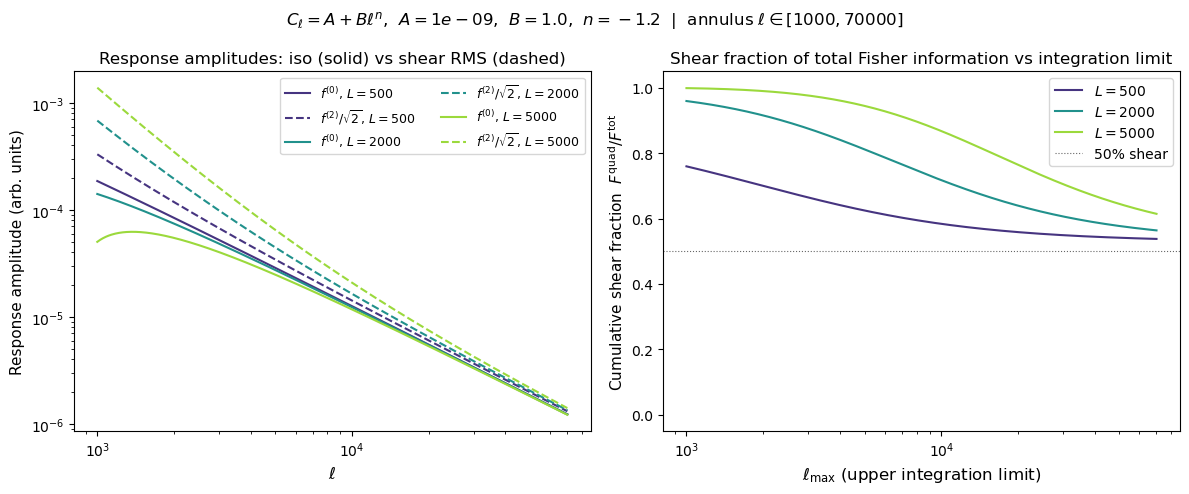

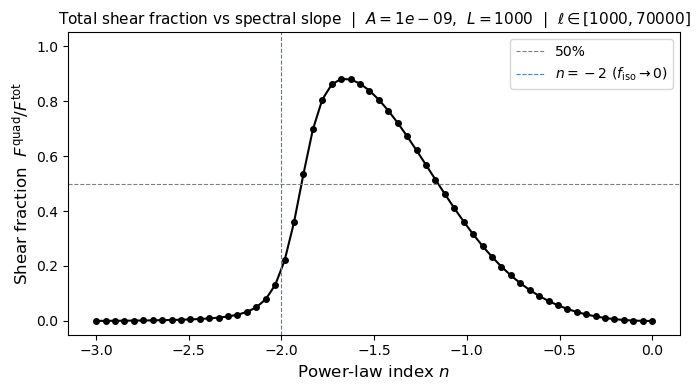

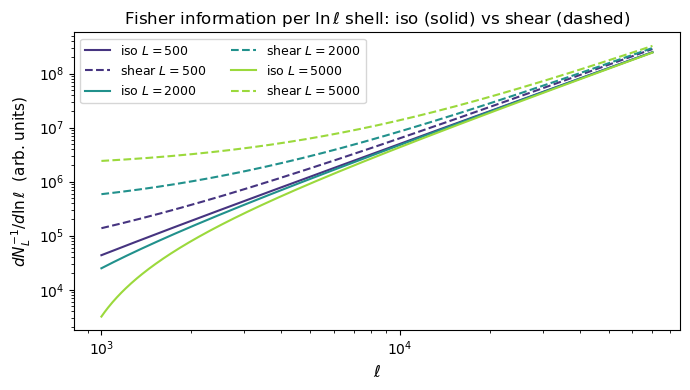

In [2]:
"""
Quantify the relative contribution of isotropic (magnification) and
quadrupolar (shear) response pieces to the total QE Fisher information.

For a power spectrum C_ell = A + B * ell^n, computes:
  - 1D radial profiles of f_iso and f_quad_amp (RMS over angle)
  - the integrand dN_L^{-1}/d(ln ell) for each piece
  - the cumulative Fisher information and shear fraction vs ell
  - the shear fraction as a function of n (for fixed A)
"""

# ---------------------------------------------------------------------------
# Plot 1: radial profiles and Fisher integrands for a few L values
# ---------------------------------------------------------------------------


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------


# Power spectrum
A = 1e-9
B = 1.0
n = -1.2

# Annulus
ellmin =  1_000.0
ellmax = 70_000.0

# L values
L_values = [500, 2000, 5000]

# Plot 1: profiles + cumulative shear fraction
plot_profiles_and_fisher(
    L_values=L_values, A=A, B=B, n=n,
    ellmin=ellmin, ellmax=ellmax
)

# Plot 2: shear fraction vs spectral index
n_values = np.linspace(-3.0, 0.0, 60)
plot_shear_fraction_vs_n(
    n_values=n_values, A=A, B=B,
    L=1000, ellmin=ellmin, ellmax=ellmax
)

# Plot 3: Fisher integrand per shell
plot_fisher_integrand_per_shell(
    L_values=L_values, A=A, B=B, n=n,
    ellmin=ellmin, ellmax=ellmax
)

plt.show()

fsky =  0.002424066128523986
Using Gaussian beam with FWHM = 3.00 arcsec (σ = 1.27 arcsec)
Loading from  /Volumes/richext/workmac/ciber/ciber1/data/input_recovered_ps/ciber_gal_cross/WISE/TM1/ciber_gal_ps_TM1_WISE_unWISE_neo8.npz
Loaded C_L^kg with scale factor 0.50
Extrapolation power law: Cl ∝ ell^-1.544 for ell > 9480
Adding non-Gaussian N_L^kappa: 5.00e-09 (ratio to mean Gaussian noise: 7.96)
Computing SNR vs tracer density (Adeg=1000.0 deg^2)...
Computing SNR vs sky area (nbar=100000 deg^-2)...


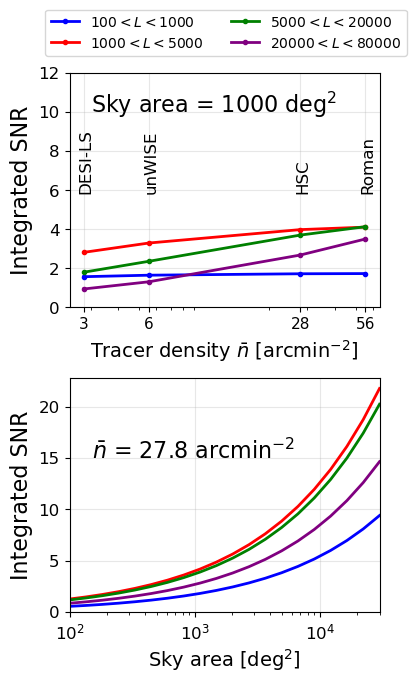


Integrated SNR Summary

At Adeg=1000 deg^2, nbar=100000 deg^-2:
  L=[100, 1e+03]: SNR = 1.7
  L=[1000, 5e+03]: SNR = 4.0
  L=[5000, 2e+04]: SNR = 3.7
  L=[20000, 8e+04]: SNR = 2.7


In [12]:
from forecast_cib_lens import plot_integrated_snr_vs_survey_params


# survey_labels=['HSC', 'unWISE', 'Euclid', 'Rubin', 'Roman-shallow', 'Roman-deep']
survey_labels=['DESI-LS', 'unWISE', 'HSC', 'Roman']

nbar_list = [1e4, 2e4, 1e5, 2e5]

Adeg_list = np.logspace(2, np.log10(3e4), 20)
# Adeg_list = [100, 1000, 1e4]

# Create SNR plots
fig, snr_dict = plot_integrated_snr_vs_survey_params(
    nbar_list=nbar_list,
    Adeg_list=Adeg_list,
    L_ranges=[(100, 1000), (1000, 5000), (5000, 20000), (20000, 80000)],
    catname='WISE',
    addstr='unWISE_neo8',
    Adeg_fixed=1000,
    nbar_fixed=1e5,
    figsize=(4, 7),
    survey_labels=survey_labels,
    bbox_to_anchor=[-0.1, 1.3],
    legend_fs=10,
    psf_fwhm=3.0,
    ylim=[0, 12],
    text_fs=12, 
    textypos=6,
    textypos2=15,
    nl_kappa_nongauss=5e-9,
    
)

fig.savefig('../figures/clkg_lensing_forecast_hscdensity_022526.png', bbox_inches='tight')

# Access results
# print(snr_dict['snr_vs_nbar'])  # SNR for each L range vs nbar
# print(snr_dict['snr_vs_area'])  # SNR for each L range vs area

In [2]:
cbps = CIBER_PS_pipeline()

print(cbps.Mkk_obj.midbin_ell)
print(cbps.Mkk_obj.binl)

clf = ciber_lens_forecast(ell_min=210, Adeg=1000)

[   207.14163673    269.61011511    350.91744625    456.74493344
    594.48721188    773.76894458   1007.11734018   1310.83748448
   1706.15164905   2220.68218525   2890.38162032   3762.04481964
   4896.57875121   6373.25832528   8295.26568336  10796.89999141
  14052.96151735  18290.9656999   23807.04065987  30986.61898336
  40331.36960354  52494.25163072  68325.13949706  88930.20744695
 115749.22283032]
[   180.            234.28327345    304.93695677    396.89793572
    516.59193115    672.38249261    875.15539655   1139.0792838
   1482.59568517   1929.70761293   2511.65675757   3269.10648307
   4254.98315621   5538.17434622   7208.34230435   9382.18906237
  12211.61092044  15894.31211426  20687.61928555  26926.46203418
  35046.77593253  45615.96327455  59372.53998689  77277.73900723
 100582.67588667 130915.76977397]
fsky =  0.02424066128523986


fsky =  0.002424066128523986
KeysView(NpzFile '/Users/richardfeder/Documents/ciber/data/fluctuation_data/TM1//beam_correction/bl_est_postage_stamps_TM1_081121.npz' with keys: B_ells_post, ifield_list)
Loading from  ../data/lens_prods/ciber_gal_cross/WISE/TM1/ciber_gal_ps_TM1_WISE_unWISE_neo8.npz
Loaded C_L^kg with scale factor 0.50
Extrapolation power law: Cl ∝ ell^-1.544 for ell > 9480
Adding non-Gaussian N_L^kappa: 5.00e-09 (ratio to mean Gaussian noise: 3.90)
fsky =  0.002424066128523986
KeysView(NpzFile '/Users/richardfeder/Documents/ciber/data/fluctuation_data/TM1//beam_correction/bl_est_postage_stamps_TM1_081121.npz' with keys: B_ells_post, ifield_list)
Loading from  ../data/lens_prods/ciber_gal_cross/WISE/TM1/ciber_gal_ps_TM1_WISE_unWISE_neo8.npz
Loaded C_L^kg with scale factor 0.50
Extrapolation power law: Cl ∝ ell^-1.544 for ell > 9480
Adding non-Gaussian N_L^kappa: 5.00e-09 (ratio to mean Gaussian noise: 3.90)
fsky =  0.002424066128523986
KeysView(NpzFile '/Users/richardfeder

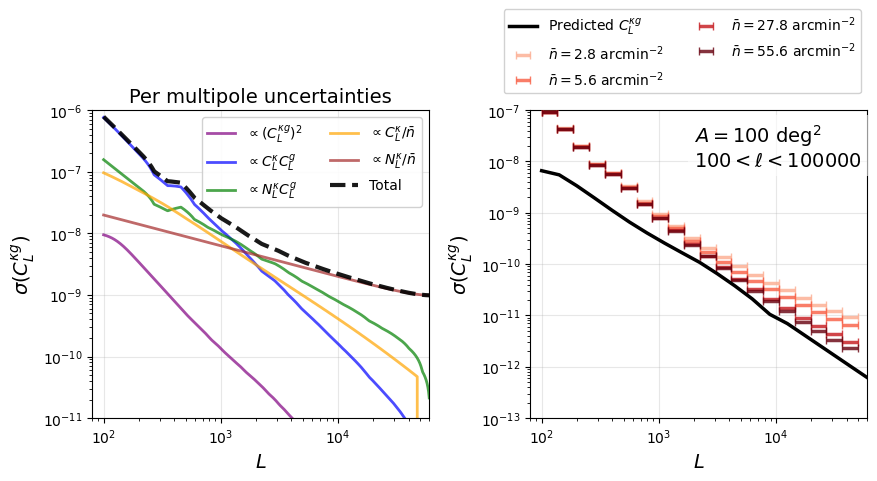

fsky =  0.02424066128523986
KeysView(NpzFile '/Users/richardfeder/Documents/ciber/data/fluctuation_data/TM1//beam_correction/bl_est_postage_stamps_TM1_081121.npz' with keys: B_ells_post, ifield_list)
Loading from  ../data/lens_prods/ciber_gal_cross/WISE/TM1/ciber_gal_ps_TM1_WISE_unWISE_neo8.npz
Loaded C_L^kg with scale factor 0.50
Extrapolation power law: Cl ∝ ell^-1.544 for ell > 9480
Adding non-Gaussian N_L^kappa: 5.00e-09 (ratio to mean Gaussian noise: 3.90)
fsky =  0.02424066128523986
KeysView(NpzFile '/Users/richardfeder/Documents/ciber/data/fluctuation_data/TM1//beam_correction/bl_est_postage_stamps_TM1_081121.npz' with keys: B_ells_post, ifield_list)
Loading from  ../data/lens_prods/ciber_gal_cross/WISE/TM1/ciber_gal_ps_TM1_WISE_unWISE_neo8.npz
Loaded C_L^kg with scale factor 0.50
Extrapolation power law: Cl ∝ ell^-1.544 for ell > 9480
Adding non-Gaussian N_L^kappa: 5.00e-09 (ratio to mean Gaussian noise: 3.90)
fsky =  0.02424066128523986
KeysView(NpzFile '/Users/richardfeder/Do

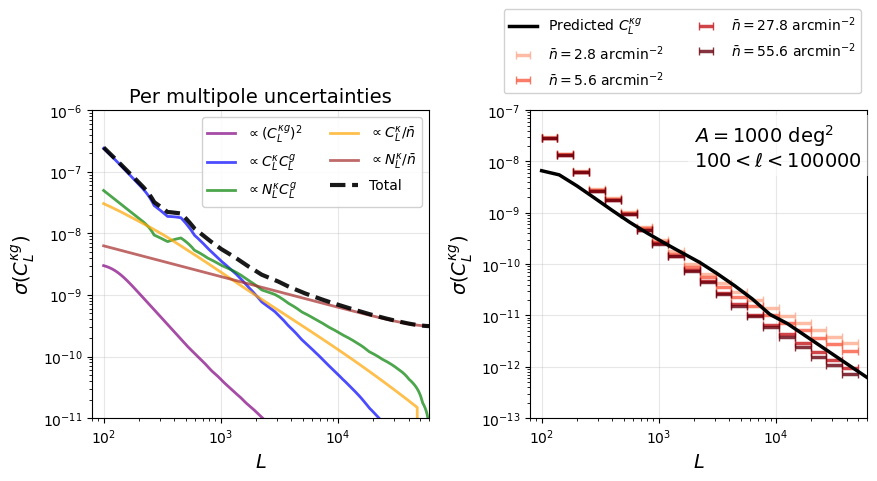

fsky =  0.33936925799335804
KeysView(NpzFile '/Users/richardfeder/Documents/ciber/data/fluctuation_data/TM1//beam_correction/bl_est_postage_stamps_TM1_081121.npz' with keys: B_ells_post, ifield_list)
Loading from  ../data/lens_prods/ciber_gal_cross/WISE/TM1/ciber_gal_ps_TM1_WISE_unWISE_neo8.npz
Loaded C_L^kg with scale factor 0.50
Extrapolation power law: Cl ∝ ell^-1.544 for ell > 9480
Adding non-Gaussian N_L^kappa: 5.00e-09 (ratio to mean Gaussian noise: 3.90)
fsky =  0.33936925799335804
KeysView(NpzFile '/Users/richardfeder/Documents/ciber/data/fluctuation_data/TM1//beam_correction/bl_est_postage_stamps_TM1_081121.npz' with keys: B_ells_post, ifield_list)
Loading from  ../data/lens_prods/ciber_gal_cross/WISE/TM1/ciber_gal_ps_TM1_WISE_unWISE_neo8.npz
Loaded C_L^kg with scale factor 0.50
Extrapolation power law: Cl ∝ ell^-1.544 for ell > 9480
Adding non-Gaussian N_L^kappa: 5.00e-09 (ratio to mean Gaussian noise: 3.90)
fsky =  0.33936925799335804
KeysView(NpzFile '/Users/richardfeder/Do

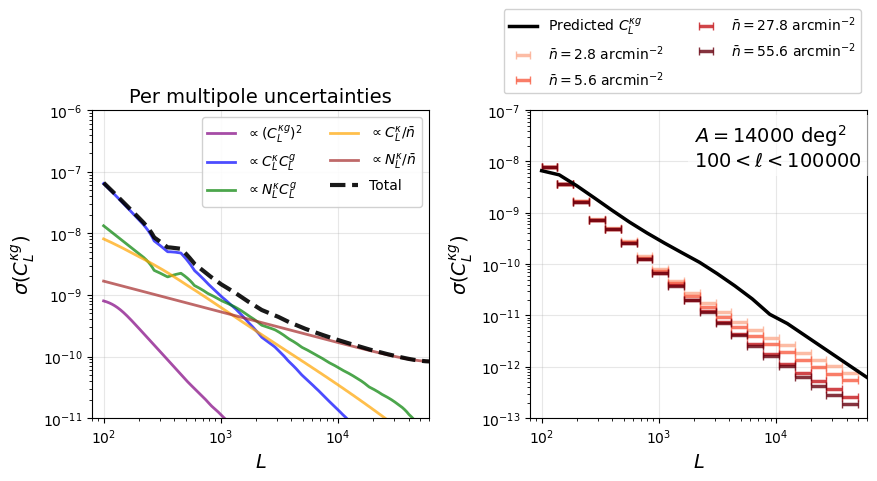

fsky =  0.7272198385571959
KeysView(NpzFile '/Users/richardfeder/Documents/ciber/data/fluctuation_data/TM1//beam_correction/bl_est_postage_stamps_TM1_081121.npz' with keys: B_ells_post, ifield_list)
Loading from  ../data/lens_prods/ciber_gal_cross/WISE/TM1/ciber_gal_ps_TM1_WISE_unWISE_neo8.npz
Loaded C_L^kg with scale factor 0.50
Extrapolation power law: Cl ∝ ell^-1.544 for ell > 9480
Adding non-Gaussian N_L^kappa: 5.00e-09 (ratio to mean Gaussian noise: 3.90)
fsky =  0.7272198385571959
KeysView(NpzFile '/Users/richardfeder/Documents/ciber/data/fluctuation_data/TM1//beam_correction/bl_est_postage_stamps_TM1_081121.npz' with keys: B_ells_post, ifield_list)
Loading from  ../data/lens_prods/ciber_gal_cross/WISE/TM1/ciber_gal_ps_TM1_WISE_unWISE_neo8.npz
Loaded C_L^kg with scale factor 0.50
Extrapolation power law: Cl ∝ ell^-1.544 for ell > 9480
Adding non-Gaussian N_L^kappa: 5.00e-09 (ratio to mean Gaussian noise: 3.90)
fsky =  0.7272198385571959
KeysView(NpzFile '/Users/richardfeder/Docum

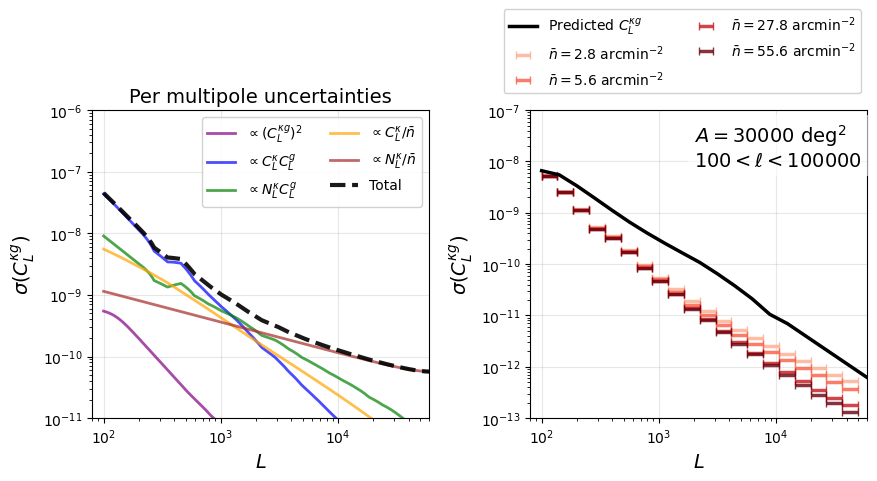

In [14]:
# Adeg = 10000

# Adeg_list = [16]
Adeg_list = [100, 1000, 14000, 30000]

for Adeg in Adeg_list:

    fig, results = compare_forecast_configurations(
        inst=1,
        Adeg_list=[Adeg],
        nbar_list=[1e4, 2e4, 1e5, 2e5],
        L_min=100,
        L_max=50000,
        n_bins=20,
        ylim_kg=[1e-13, 1e-7],
        figsize=(10, 4),
        ylim_kk=[1e-11, 1e-6],
        textkg='$A='+str(Adeg)+'$ deg$^2$\n$100<\\ell<100000$',
        bbox_to_anchor=[-0.1, 1.35],
        legend_ncol=2,
        textkg_xpos=2000,
        textkg_ypos=8e-9,
        legend_fs=10,
        textkg_fs=14,
        cmap_name="Reds",
        ell_max=70000.,
        ell_min=100.,
        nl_kappa_nongauss=5e-9
    )

    fig.savefig('../figures/clkg_forecast_vary_nbar_Adeg='+str(Adeg)+'_deg2_1.1um_ellmax=100000_022526.png', bbox_inches='tight', dpi=200)

fsky =  0.02424066128523986
KeysView(NpzFile '/Users/richardfeder/Documents/ciber/data/fluctuation_data/TM1//beam_correction/bl_est_postage_stamps_TM1_081121.npz' with keys: B_ells_post, ifield_list)
Loading from  ../data/lens_prods/ciber_gal_cross/WISE/TM1/ciber_gal_ps_TM1_WISE_unWISE_neo8.npz
Extrapolation power law: Cl ∝ ell^-1.544 for ell > 9480


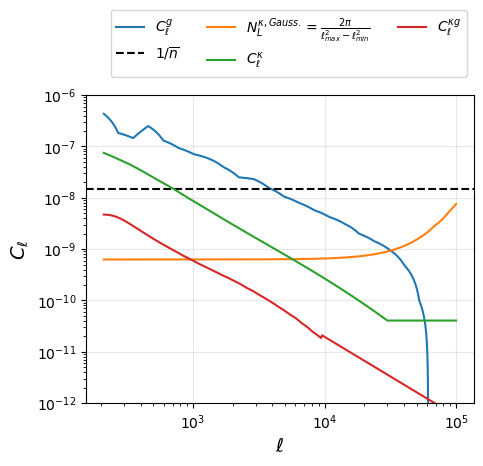

/Users/richardfeder/Documents/ciber/FlatSkyQE/forecast_cib_lens.py:385: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(self.lrange, np.sqrt(inverse_nl*terms[x]), label=labels[x])


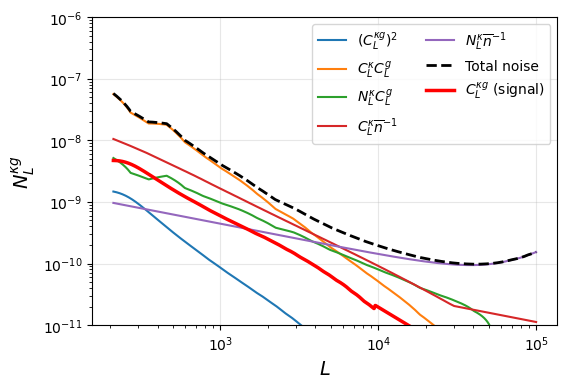

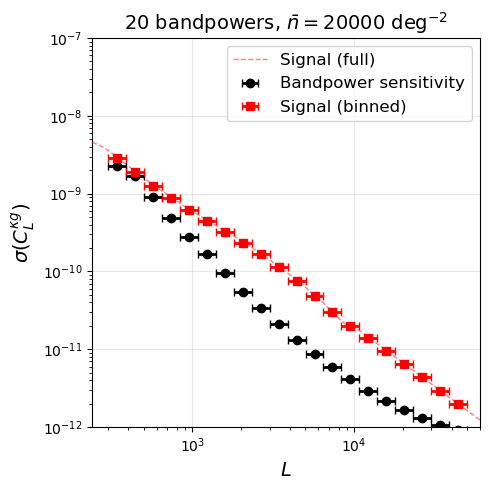

In [9]:
clf, dcl = perform_clkg_forecast_wrapper(Adeg=1000.)

# Show bandpower sensitivity
L_centers, sigma_bp, signal_bp, fig = clf.forecast_kappa_gal_cross_bandpowers(
    nbar=2e4,  # deg^-2
    L_min=300, 
    L_max=50000, 
    n_bins=20,
    ylim=[1e-12, 1e-7],
    figsize=(5, 5)
)

lcen: [  235.4006978    295.79079061   371.67345988   467.02319737
   586.83411763   737.38153385   926.55063863  1164.24950522
  1462.92804073  1838.23007247  2309.81272165  2902.37598057
  3646.9564193   4582.55278202  5758.16861668  7235.37892422
  9091.55526036 11423.91821049 14354.62949326 18037.19040107
 22664.48170724 28478.86614467 35784.88259129 44965.19684342
 56500.64442741 70995.41522813 89208.69902448]


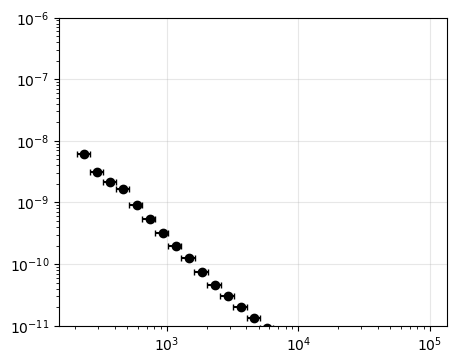

In [8]:
# dcl = np.sqrt(dclsq)

lEdges = np.logspace(np.log10(np.min(clf.lrange)), np.log10(np.max(clf.lrange)), 28)

lEdges_use = lEdges.copy()

lcen = np.sqrt(lEdges[:-1]*lEdges[1:])

print('lcen:', lcen)

dcl_bandpowers = np.zeros_like(lcen)

for x in range(len(lEdges)-1):
    delta_ell = lEdges[x+1]-lEdges[x]
    
    dcl_bandpowers[x] = np.mean(dcl[(clf.lrange > lEdges[x])*(clf.lrange < lEdges[x+1])])/np.sqrt(delta_ell)

    
plt.figure(figsize=(5, 4))
plt.errorbar(lcen, dcl_bandpowers, xerr=[lEdges[1:]-lcen, lcen-lEdges[:-1]], fmt='o', capsize=2, color='k')
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.ylim(1e-11, 1e-6)
plt.show()